# Cell Matcher End-to-End Analysis

Notebook ini mencakup: EDA, analisis feature engineering, evaluasi model, dan inferensi + rekomendasi pack untuk proyek ReVoltz Cell Matcher.

In [12]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

from src.config import DATA_DIR, ARTIFACTS_DIR, DEFAULT_SNAPSHOT_CYCLE
from src.data_loader import load_all_cells, extract_capacity_fade
from src.feature_extractor import extract_features_per_cell, extract_snapshot_features
from src.labeler import generate_compatibility_pairs
from src.model import CellMatcher
from src.predictor import predict_cells_with_recommendations

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

print(f'DATA_DIR: {DATA_DIR}')
print(f'ARTIFACTS_DIR: {ARTIFACTS_DIR}')
print(f'DEFAULT_SNAPSHOT_CYCLE: {DEFAULT_SNAPSHOT_CYCLE}')

DATA_DIR: D:\CompSci\Lain lain\IYREF\battery-cell-matcher\data\hnei
ARTIFACTS_DIR: D:\CompSci\Lain lain\IYREF\battery-cell-matcher\artifacts
DEFAULT_SNAPSHOT_CYCLE: 100


In [13]:
cells = load_all_cells(DATA_DIR)
print(f'Total cells loaded: {len(cells)}')

dataset_rows = []
for cell in cells:
    dataset_rows.append({
        'cell_id': cell.get('cell_id'),
        'chemistry': cell.get('cathode_material'),
        'nominal_capacity_Ah': cell.get('nominal_capacity_in_Ah'),
        'n_cycles': len(cell.get('cycle_data', []))
    })

df_dataset = pd.DataFrame(dataset_rows)
display(df_dataset)
display(df_dataset.describe(include='all').T)

Total cells loaded: 14


,cell_id,chemistry,nominal_capacity_Ah,n_cycles
0,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,LiCoO2+LiNi0.4Co0.4Mn0.2O2,2.8,1086
1,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_b,LiCoO2+LiNi0.4Co0.4Mn0.2O2,2.8,1080
2,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_c,LiCoO2+LiNi0.4Co0.4Mn0.2O2,2.8,1081
3,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_d,LiCoO2+LiNi0.4Co0.4Mn0.2O2,2.8,1081
4,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_e,LiCoO2+LiNi0.4Co0.4Mn0.2O2,2.8,1107
5,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_f,LiCoO2+LiNi0.4Co0.4Mn0.2O2,2.8,1075
6,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_g,LiCoO2+LiNi0.4Co0.4Mn0.2O2,2.8,1082
7,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_j,LiCoO2+LiNi0.4Co0.4Mn0.2O2,2.8,1076
8,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_l,LiCoO2+LiNi0.4Co0.4Mn0.2O2,2.8,1081
9,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_n,LiCoO2+LiNi0.4Co0.4Mn0.2O2,2.8,1082


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cell_id,14,14,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chemistry,14,1,LiCoO2+LiNi0.4Co0.4Mn0.2O2,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nominal_capacity_Ah,14.0,NaN,NaN,NaN,2.8,0.0,2.8,2.8,2.8,2.8,2.8
n_cycles,14.0,NaN,NaN,NaN,1083.142857,7.624426,1075.0,1080.25,1081.5,1082.75,1107.0


Capacity rows: 15,155


,cell_id,cycle,capacity_Ah,SoH
0,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,1,2.638,0.942143
1,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,2,2.638,0.942143
2,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,3,2.638,0.942143
3,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,4,2.638,0.942143
4,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,5,2.638,0.942143


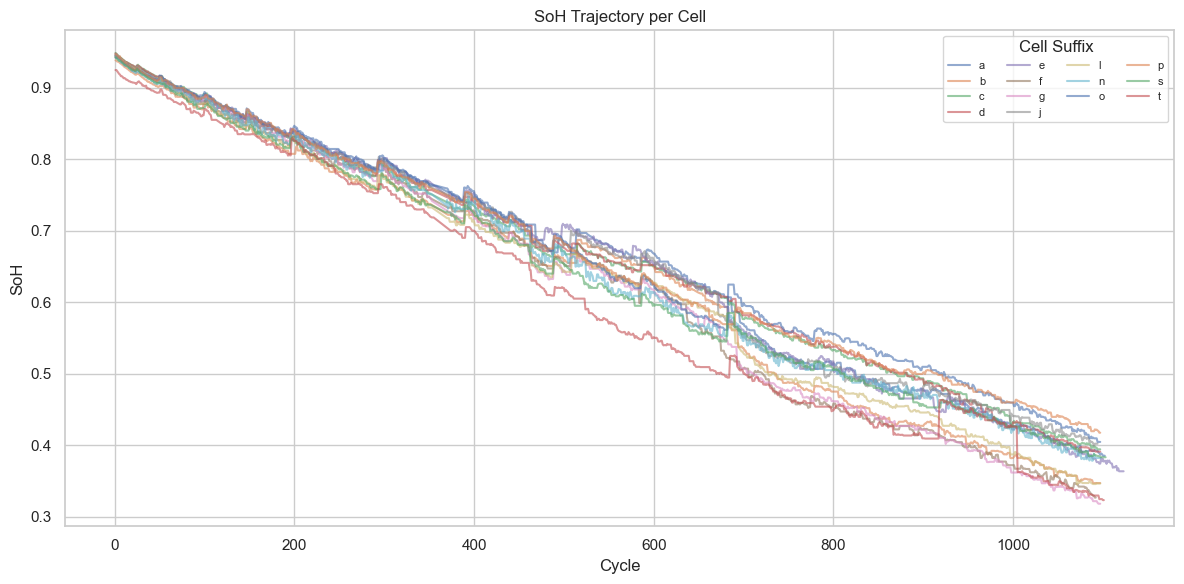

In [14]:
capacity_frames = []
for cell in cells:
    df_cap = extract_capacity_fade(cell)
    if not df_cap.empty:
        capacity_frames.append(df_cap)

df_capacity = pd.concat(capacity_frames, ignore_index=True)
print(f'Capacity rows: {len(df_capacity):,}')
display(df_capacity.head())

plt.figure(figsize=(12, 6))
for cell_id, group in df_capacity.groupby('cell_id'):
    plt.plot(group['cycle'], group['SoH'], alpha=0.6, label=cell_id.split('_')[-1])

plt.title('SoH Trajectory per Cell')
plt.xlabel('Cycle')
plt.ylabel('SoH')
plt.legend(title='Cell Suffix', ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

In [15]:
feature_frames = []
for cell in cells:
    df_feat = extract_features_per_cell(cell)
    if not df_feat.empty:
        feature_frames.append(df_feat)

df_features = pd.concat(feature_frames, ignore_index=True)
print(f'Feature rows: {len(df_features):,}')
display(df_features.head())

missing_report = df_features[['IR_ohm', 'OCV_V', 'SoH']].isna().mean().rename('missing_ratio')
display(missing_report.to_frame())

Feature rows: 15,155


,cell_id,cycle,capacity_Ah,SoH,OCV_V,IR_ohm,chemistry
0,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,1,2.638,0.942143,3.816,0.06425,LiCoO2+LiNi0.4Co0.4Mn0.2O2
1,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,2,2.638,0.942143,3.816,0.06425,LiCoO2+LiNi0.4Co0.4Mn0.2O2
2,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,3,2.638,0.942143,3.816,0.06425,LiCoO2+LiNi0.4Co0.4Mn0.2O2
3,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,4,2.638,0.942143,3.816,0.06425,LiCoO2+LiNi0.4Co0.4Mn0.2O2
4,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,5,2.638,0.942143,3.816,0.06425,LiCoO2+LiNi0.4Co0.4Mn0.2O2


,missing_ratio
IR_ohm,0.0
OCV_V,0.0
SoH,0.0


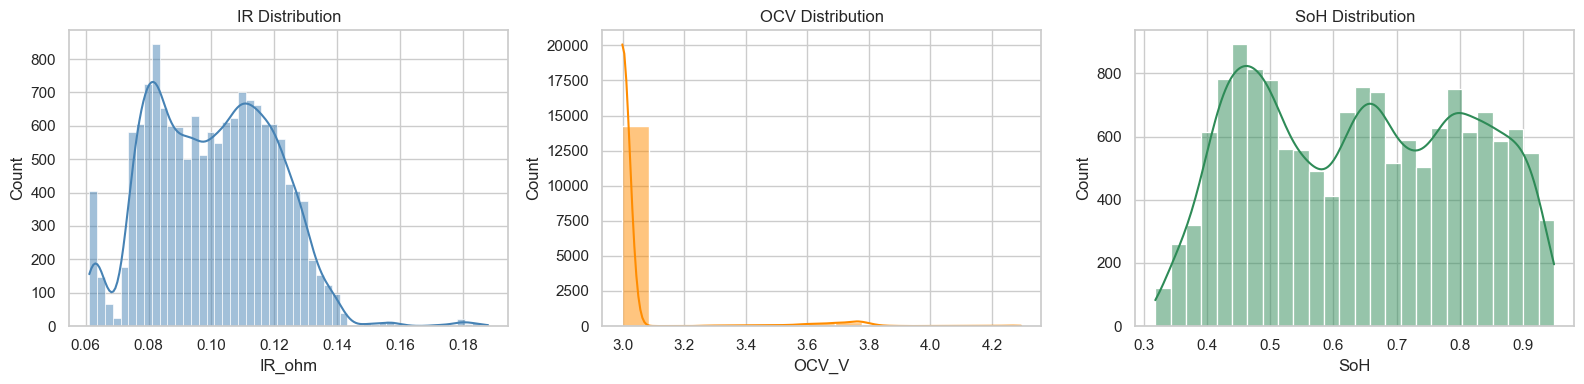

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_features['IR_ohm'].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('IR Distribution')

sns.histplot(df_features['OCV_V'].dropna(), kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('OCV Distribution')

sns.histplot(df_features['SoH'].dropna(), kde=True, ax=axes[2], color='seagreen')
axes[2].set_title('SoH Distribution')

plt.tight_layout()
plt.show()

In [17]:
snapshot_cycle = DEFAULT_SNAPSHOT_CYCLE
snapshots = []
for cell in cells:
    row = extract_snapshot_features(cell, at_cycle=snapshot_cycle)
    if row:
        snapshots.append(row)

df_snapshot = pd.DataFrame(snapshots)
df_snapshot_valid = df_snapshot.dropna(subset=['IR_ohm', 'OCV_V']).copy()

print(f'Snapshot rows @ cycle <= {snapshot_cycle}: {len(df_snapshot)}')
print(f'Valid snapshot rows (IR+OCV): {len(df_snapshot_valid)}')
display(df_snapshot_valid[['cell_id', 'cycle', 'SoH', 'IR_ohm', 'OCV_V', 'chemistry']])

Snapshot rows @ cycle <= 100: 14
Valid snapshot rows (IR+OCV): 14


,cell_id,cycle,SoH,IR_ohm,OCV_V,chemistry
0,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,100,0.882143,0.075041,2.999,LiCoO2+LiNi0.4Co0.4Mn0.2O2
1,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_b,100,0.877857,0.086997,2.999,LiCoO2+LiNi0.4Co0.4Mn0.2O2
2,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_c,100,0.891429,0.077448,3.302,LiCoO2+LiNi0.4Co0.4Mn0.2O2
3,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_d,100,0.886071,0.065952,3.525,LiCoO2+LiNi0.4Co0.4Mn0.2O2
4,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_e,100,0.886786,0.077901,3.008,LiCoO2+LiNi0.4Co0.4Mn0.2O2
5,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_f,100,0.877500,0.075241,2.999,LiCoO2+LiNi0.4Co0.4Mn0.2O2
6,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_g,100,0.887143,0.076724,2.999,LiCoO2+LiNi0.4Co0.4Mn0.2O2
7,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_j,100,0.880000,0.074335,3.770,LiCoO2+LiNi0.4Co0.4Mn0.2O2
8,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_l,100,0.878214,0.067333,3.551,LiCoO2+LiNi0.4Co0.4Mn0.2O2
9,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_n,100,0.886071,0.075711,3.275,LiCoO2+LiNi0.4Co0.4Mn0.2O2


In [18]:
model = CellMatcher()
model.fit(df_snapshot_valid, snapshot_cycle=snapshot_cycle)

print('Training metadata:')
print(json.dumps(model.metadata, indent=2))

Training metadata:
{
  "model_version": "cell_matcher_v1",
  "snapshot_cycle": 100,
  "training_samples": 14,
  "non_outlier_training_samples": 9,
  "selected_clusters": 2,
  "silhouette_score": 0.4772012499667803,
  "compatibility_thresholds": {
    "IR_ohm": 0.005,
    "OCV_V": 0.05
  },
  "iqr_bounds": {
    "IR_ohm": [
      0.06884306450779928,
      0.08550456362121325
    ],
    "OCV_V": [
      2.2936250000000005,
      4.174624999999999
    ]
  }
}


In [19]:
train_inputs = df_snapshot_valid[['cell_id', 'IR_ohm', 'OCV_V', 'chemistry']].to_dict(orient='records')
train_preds = pd.DataFrame(model.predict(train_inputs))

outlier_ratio = train_preds['is_outlier'].mean()
cluster_counts = train_preds['cluster'].value_counts(dropna=False).rename_axis('cluster').to_frame('count')

print(f'Outlier ratio on snapshot set: {outlier_ratio:.3f}')
display(cluster_counts)
display(train_preds[['cell_id', 'IR_ohm', 'OCV_V', 'is_outlier', 'cluster', 'compatible_with']])

Outlier ratio on snapshot set: 0.357


,count
cluster,
1.0,8
NaN,5
0.0,1


,cell_id,IR_ohm,OCV_V,is_outlier,cluster,compatible_with
0,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,0.075041,2.999,False,1.0,"[HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_e, HNEI..."
1,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_b,0.086997,2.999,True,NaN,[]
2,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_c,0.077448,3.302,False,1.0,"[HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_n, HNEI..."
3,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_d,0.065952,3.525,True,NaN,[]
4,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_e,0.077901,3.008,False,1.0,"[HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a, HNEI..."
5,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_f,0.075241,2.999,False,1.0,"[HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a, HNEI..."
6,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_g,0.076724,2.999,False,1.0,"[HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a, HNEI..."
7,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_j,0.074335,3.770,False,0.0,[]
8,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_l,0.067333,3.551,True,NaN,[]
9,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_n,0.075711,3.275,False,1.0,"[HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_c, HNEI..."


In [20]:
pairs_df = generate_compatibility_pairs(df_snapshot_valid)
print(f'Total generated pairs: {len(pairs_df)}')
if not pairs_df.empty:
    compatible_ratio = pairs_df['compatible'].mean()
    print(f'Compatible ratio: {compatible_ratio:.3f}')
    display(pairs_df.head(20))
    display(pairs_df[['delta_IR', 'delta_OCV']].describe().T)
else:
    print('No compatibility pairs generated.')

Total generated pairs: 91
Compatible ratio: 0.165


,cell_a,cell_b,IR_a,IR_b,OCV_a,OCV_b,delta_IR,delta_OCV,same_chemistry,compatible
0,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_b,0.075041,0.086997,2.999,2.999,0.011956,0.000,True,0
1,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_c,0.075041,0.077448,2.999,3.302,0.002407,0.303,True,0
2,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_d,0.075041,0.065952,2.999,3.525,0.009089,0.526,True,0
3,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_e,0.075041,0.077901,2.999,3.008,0.002860,0.009,True,1
4,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_f,0.075041,0.075241,2.999,2.999,0.000200,0.000,True,1
5,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_g,0.075041,0.076724,2.999,2.999,0.001683,0.000,True,1
6,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_j,0.075041,0.074335,2.999,3.770,0.000706,0.771,True,0
7,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_l,0.075041,0.067333,2.999,3.551,0.007708,0.552,True,0
8,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_n,0.075041,0.075711,2.999,3.275,0.000670,0.276,True,0
9,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a,HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_o,0.075041,0.087765,2.999,2.999,0.012724,0.000,True,0


,count,mean,std,min,25%,50%,75%,max
delta_IR,91.0,0.013914,0.018385,0.0002,0.002198,0.009089,0.012215,0.067381
delta_OCV,91.0,0.299681,0.240719,0.0000,0.013000,0.276000,0.526000,0.771000


In [21]:
# Simulasi inferensi dari sampel snapshot valid
sample_inputs = df_snapshot_valid[['cell_id', 'IR_ohm', 'OCV_V', 'chemistry']].head(8).copy()
sample_inputs['cell_id'] = [f"sim_{i+1}_{cid.split('_')[-1]}" for i, cid in enumerate(sample_inputs['cell_id'])]
cells_for_inference = sample_inputs.to_dict(orient='records')

results, packs = predict_cells_with_recommendations(
    cells=cells_for_inference,
    target_pack_size=4,
    max_packs=2,
    allow_partial_packs=True,
)

df_results = pd.DataFrame(results)
df_packs = pd.DataFrame(packs)

display(df_results[['cell_id', 'IR_ohm', 'OCV_V', 'is_outlier', 'cluster', 'status', 'compatible_with', 'recommended_pack_id']])
display(df_packs if not df_packs.empty else pd.DataFrame({'info': ['No pack recommendations for current input']}))

,cell_id,IR_ohm,OCV_V,is_outlier,cluster,status,compatible_with,recommended_pack_id
0,sim_1_a,0.075041,2.999,False,1.0,recommended,"[sim_5_e, sim_6_f, sim_7_g]",pack_1
1,sim_2_b,0.086997,2.999,True,NaN,discard,[],None
2,sim_3_c,0.077448,3.302,False,1.0,candidate,[],None
3,sim_4_d,0.065952,3.525,True,NaN,discard,[],None
4,sim_5_e,0.077901,3.008,False,1.0,recommended,"[sim_1_a, sim_6_f, sim_7_g]",pack_1
5,sim_6_f,0.075241,2.999,False,1.0,recommended,"[sim_1_a, sim_5_e, sim_7_g]",pack_1
6,sim_7_g,0.076724,2.999,False,1.0,recommended,"[sim_1_a, sim_5_e, sim_6_f]",pack_1
7,sim_8_j,0.074335,3.770,False,0.0,candidate,[],None


,pack_id,status,cluster,cell_ids,source_pack_ids,target_pack_size,cell_count,missing_cells,average_ir_ohm,average_ocv_v,average_pairwise_delta_ir,average_pairwise_delta_ocv,homogeneity_score,notes
0,pack_1,full,1,"[sim_1_a, sim_6_f, sim_7_g, sim_5_e]",[],4,4,0,0.076227,3.00125,0.001677,0.0045,0.787309,[All member cells are mutually compatible and ...


In [22]:
# Opsional: simpan artefak analisis notebook (tidak overwrite artefak training utama)
SAVE_ANALYSIS_ARTIFACTS = False

if SAVE_ANALYSIS_ARTIFACTS:
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    df_snapshot_valid.to_csv(ARTIFACTS_DIR / 'notebook_snapshot_valid.csv', index=False)
    pairs_df.to_csv(ARTIFACTS_DIR / 'notebook_compatibility_pairs.csv', index=False)
    pd.DataFrame(results).to_csv(ARTIFACTS_DIR / 'notebook_inference_results.csv', index=False)
    if isinstance(df_packs, pd.DataFrame) and not df_packs.empty:
        df_packs.to_csv(ARTIFACTS_DIR / 'notebook_recommended_packs.csv', index=False)
    print('Notebook analysis artifacts saved.')
else:
    print('SAVE_ANALYSIS_ARTIFACTS=False, no files were written.')

SAVE_ANALYSIS_ARTIFACTS=False, no files were written.


## Catatan Evaluasi

- Pipeline ini bersifat **unsupervised + rule-based**.
- Silhouette score dan rasio compatible membantu mengecek kualitas grouping, tapi bukan accuracy klasifikasi supervised.
- Untuk peningkatan berikutnya: kalibrasi threshold IR/OCV dari data bengkel nyata dan validasi domain dengan ground truth repack hasil lapangan.